In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [30]:
X, y = make_classification(n_samples=2000,
                           n_features=5,
                           n_informative=5,
                           n_redundant=0,
                           n_classes=5,
                           class_sep=2,
                           random_state=42)

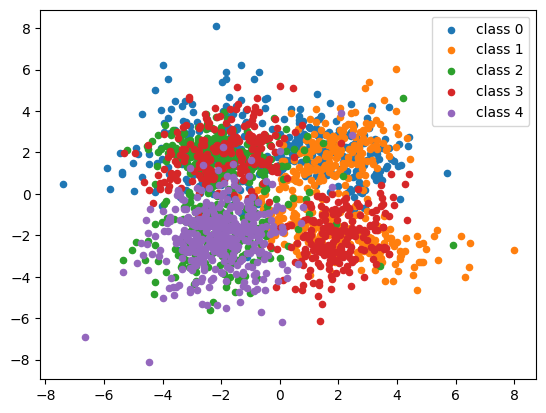

In [31]:
for cls in np.unique(y):
    plt.scatter(X[y==cls,0], X[y==cls,1], label=f'class {cls}', s=20)
plt.legend()
plt.show()

In [32]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def _add_bias(self, X): # addded this
        X = np.atleast_2d(X)
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        Xb = self._add_bias(X) # added this
        m = Xb.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(Xb, y, start_b, self._n_iters)


class LogReg(SGD):
    def sigmoid(self, X, b):
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        return 1. / n * X.T.dot(self.sigmoid(X, b) - y)

    def predict_proba(self, X):
        Xb = self._add_bias(X) # bias here
        return self.sigmoid(Xb, self.b)

    def predict(self, X):
        return self.predict_proba(X) > 0.5

In [33]:
ovr_models = {}
for cls in np.unique(y):
    y_bin = (y == cls).astype(int) # binary labels for current class
    model = LogReg(alpha=0.5, n_iters=2000)
    model.fit(X, y_bin)
    ovr_models[cls] = model

In [34]:
probs = np.vstack([ovr_models[cls].predict_proba(X) for cls in sorted(ovr_models)]).T
y_pred_ovr = np.argmax(probs, axis=1)

In [35]:
print(accuracy_score(y, y_pred_ovr))

0.8


In [39]:
sk_model = LogisticRegression(max_iter=2000)
sk_model.fit(X, y)
y_pred_sk = sk_model.predict(X)
print('sklearn accuracy:', accuracy_score(y, y_pred_sk))

sklearn accuracy: 0.806


In [48]:
probs_sk = sk_model.predict_proba(X)
print()
for a in probs_sk[:5]:
    print([round(float(x), 3) for x in a])


[0.009, 0.0, 0.008, 0.084, 0.899]
[0.003, 0.0, 0.99, 0.007, 0.0]
[0.755, 0.011, 0.019, 0.215, 0.0]
[0.17, 0.0, 0.516, 0.24, 0.074]
[0.991, 0.0, 0.004, 0.005, 0.0]
